In [2]:
import pandas as pd

sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

In [3]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [4]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [6]:
print(sentiment.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
None


In [7]:
print(trades.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [12]:
# Sentiment
sentiment['date'] = pd.to_datetime(sentiment['date'])

# Trades
trades['date'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True,
    errors='coerce'
)

In [13]:
trades['date'].isna().sum()

np.int64(0)

In [14]:
merged = pd.merge(trades, sentiment, on='date', how='left')

In [15]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02 22:50:00,NaN,NaN,NaN
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02 22:50:00,NaN,NaN,NaN
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02 22:50:00,NaN,NaN,NaN
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02 22:50:00,NaN,NaN,NaN
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02 22:50:00,NaN,NaN,NaN


In [16]:
merged['profit'] = merged['Closed PnL']
merged['is_profit'] = merged['profit'] > 0

In [17]:
merged['Side'] = merged['Side'].str.lower()

In [18]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification,profit,is_profit
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,buy,2024-12-02 22:50:00,0.000000,Buy,0.0,...,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02 22:50:00,NaN,NaN,NaN,0.0,False
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,buy,2024-12-02 22:50:00,986.524596,Buy,0.0,...,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02 22:50:00,NaN,NaN,NaN,0.0,False
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,buy,2024-12-02 22:50:00,1002.518996,Buy,0.0,...,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02 22:50:00,NaN,NaN,NaN,0.0,False
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,buy,2024-12-02 22:50:00,1146.558564,Buy,0.0,...,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02 22:50:00,NaN,NaN,NaN,0.0,False
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,buy,2024-12-02 22:50:00,1289.488521,Buy,0.0,...,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02 22:50:00,NaN,NaN,NaN,0.0,False


In [19]:
merged['return'] = merged['profit'] / merged['Size USD']

In [20]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Fee,Trade ID,Timestamp,date,timestamp,value,classification,profit,is_profit,return
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,buy,2024-12-02 22:50:00,0.000000,Buy,0.0,...,0.345404,8.950000e+14,1.730000e+12,2024-12-02 22:50:00,NaN,NaN,NaN,0.0,False,0.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,buy,2024-12-02 22:50:00,986.524596,Buy,0.0,...,0.005600,4.430000e+14,1.730000e+12,2024-12-02 22:50:00,NaN,NaN,NaN,0.0,False,0.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,buy,2024-12-02 22:50:00,1002.518996,Buy,0.0,...,0.050431,6.600000e+14,1.730000e+12,2024-12-02 22:50:00,NaN,NaN,NaN,0.0,False,0.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,buy,2024-12-02 22:50:00,1146.558564,Buy,0.0,...,0.050043,1.080000e+15,1.730000e+12,2024-12-02 22:50:00,NaN,NaN,NaN,0.0,False,0.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,buy,2024-12-02 22:50:00,1289.488521,Buy,0.0,...,0.003055,1.050000e+15,1.730000e+12,2024-12-02 22:50:00,NaN,NaN,NaN,0.0,False,0.0


In [21]:
merged.groupby('classification')['profit'].mean()

classification
Extreme Fear    -23.260258
Extreme Greed     8.401634
Fear              3.269807
Greed             7.398914
Neutral           0.000000
Name: profit, dtype: float64

In [22]:
merged.groupby('classification')['is_profit'].mean()

classification
Extreme Fear     0.000000
Extreme Greed    0.195652
Fear             0.280000
Greed            0.363636
Neutral          0.000000
Name: is_profit, dtype: float64

In [23]:
merged.groupby('classification')['Size USD'].mean()

classification
Extreme Fear      349.568571
Extreme Greed    3853.764783
Fear             1598.544000
Greed            5464.241212
Neutral          7234.347500
Name: Size USD, dtype: float64

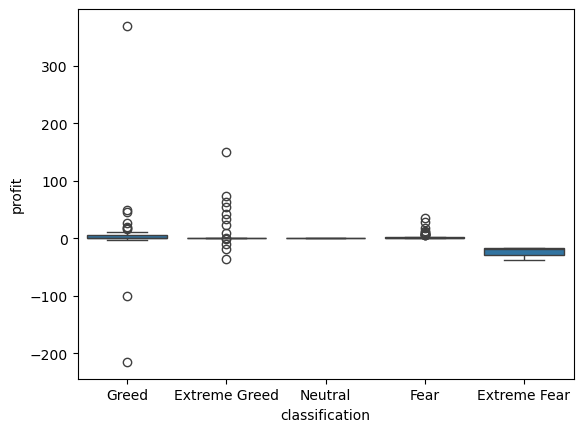

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='classification', y='profit', data=merged)
plt.show()

Profitability is lowest during Extreme Fear, with mostly negative returns, while Greed and Extreme Greed show higher and more variable profits, indicating higher risk and reward.

<Axes: xlabel='classification', ylabel='is_profit'>

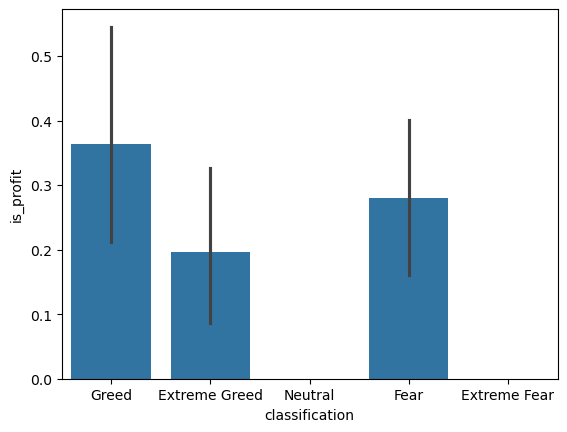

In [25]:
sns.barplot(x='classification', y='is_profit', data=merged)

Win rates are highest during Greed and lowest during Extreme Fear, showing that traders are more successful in optimistic market conditions.

In [26]:
trader_perf = merged.groupby('Account')['profit'].mean()

top_traders = trader_perf[trader_perf > trader_perf.mean()].index

merged['trader_type'] = merged['Account'].apply(
    lambda x: 'top' if x in top_traders else 'normal'
)

In [27]:
merged.groupby(['trader_type','classification'])['profit'].mean()

trader_type  classification
normal       Extreme Fear     -23.260258
             Extreme Greed      9.201789
             Fear               8.604755
             Greed              1.931777
             Neutral            0.000000
top          Extreme Greed      0.000000
             Fear               0.000000
             Greed             13.959478
Name: profit, dtype: float64

In [28]:
merged.groupby('classification')['Trade ID'].count()

classification
Extreme Fear      7
Extreme Greed    46
Fear             50
Greed            33
Neutral           8
Name: Trade ID, dtype: int64

In [29]:
merged.groupby(['classification','Side'])['profit'].mean()

classification  Side
Extreme Fear    sell   -23.260258
Extreme Greed   buy      5.001358
                sell    14.777150
Fear            buy      1.944108
                sell     7.042950
Greed           buy    -12.582050
                sell    31.376071
Neutral         buy      0.000000
                sell     0.000000
Name: profit, dtype: float64

<Axes: xlabel='date'>

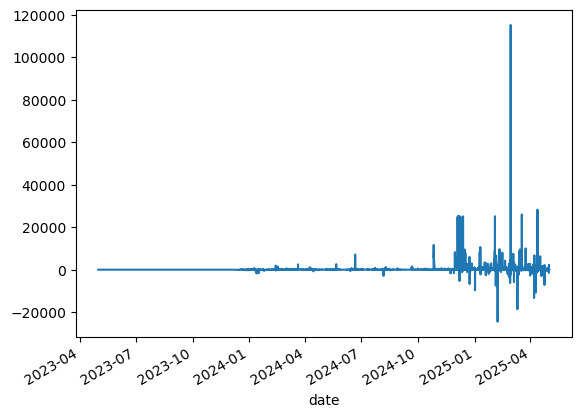

In [30]:
merged.groupby('date')['profit'].mean().plot()

In [31]:
y = merged['is_profit']

In [32]:
X = merged[[
    'Size USD',
    'Execution Price',
    'Side',
    'classification'
]]

In [33]:
X = pd.get_dummies(X, drop_first=True)

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [35]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [36]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8523138832997988
              precision    recall  f1-score   support

       False       0.87      0.88      0.88     24802
        True       0.83      0.81      0.82     17443

    accuracy                           0.85     42245
   macro avg       0.85      0.85      0.85     42245
weighted avg       0.85      0.85      0.85     42245



In [37]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False))

Execution Price                 0.584339
Size USD                        0.336646
Side_sell                       0.078794
classification_Greed            0.000070
classification_Extreme Greed    0.000066
classification_Fear             0.000064
classification_Neutral          0.000020
dtype: float64


Traders perform worst during Extreme Fear, showing consistent losses and very low win rates, while profitability and success rates improve in Greed and Extreme Greed phases. Traders also take significantly larger positions during greedy markets, indicating higher risk appetite.
However, the model shows that trade-specific factors like execution price and trade size drive profitability, while market sentiment has minimal impact on predicting individual trade outcomes.